In [1]:
!pip install xgboost statsmodels tensorflow scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\Banking_final_model_ready.csv")

print(df.head())
print(df.columns)

         Date     Open     High      Low    Close        Volume     Turn Over  \
0  2021-09-12  1937.60  1958.79  1931.74  1956.38  1.098566e+09  2.149212e+12   
1  2021-09-13  1961.42  1993.64  1958.75  1973.45  1.550711e+09  3.060250e+12   
2  2021-09-14  1975.84  1986.75  1962.17  1969.35  1.036858e+09  2.041936e+12   
3  2021-09-15  1970.10  1973.67  1945.71  1948.69  7.846501e+08  1.529040e+12   
4  2021-09-16  1950.54  1950.96  1899.20  1907.55  1.622367e+09  3.094746e+12   

   Log_Return  Return_5D  Return_10D  ...  Volume_Ratio_20D  Volume_Spike  \
0    0.012421   0.018630   -0.033920  ...          0.539891         False   
1    0.008687  -0.012683   -0.010891  ...          0.771160         False   
2   -0.002080   0.001893   -0.001445  ...          0.531577         False   
3   -0.010546   0.007387   -0.016081  ...          0.442323         False   
4   -0.021338  -0.012773   -0.028886  ...          0.953123         False   

   Cumulative_Return  Running_Max_Close  Drawdown 

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [5]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Now remove the original Date column
df = df.drop(columns=['Date'])

In [6]:
X = df.drop(columns=[
    'Target_Next_1D_Return',
    'Target_Next_1D_Direction'
])

y = df['Target_Next_1D_Return']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
    random_state=42
)

# XGBOOST Regression

In [8]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [9]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [10]:
pred = xgb.predict(X_test)

In [11]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, pred))
xgb_mae = mean_absolute_error(y_test, pred)
xgb_r2 = r2_score(y_test, pred)

print("========== XGBoost Results ==========")
print("RMSE :", xgb_rmse)
print("MAE  :", xgb_mae)
print("R²   :", xgb_r2)

========== XGBoost Results ==========
RMSE : 0.012414087169305456
MAE  : 0.008761938529635426
R²   : -0.14588003900171453


# Actual vs Predicted Plot

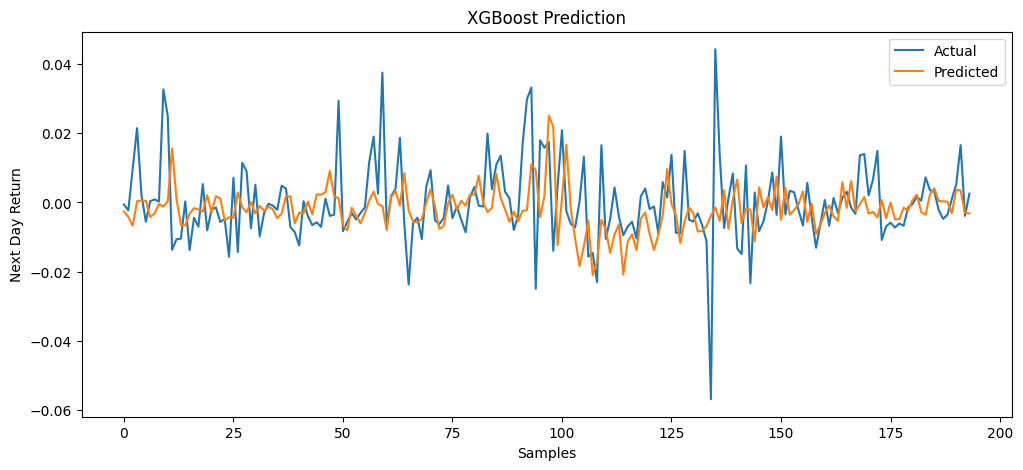

In [12]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("XGBoost Prediction")

plt.xlabel("Samples")

plt.ylabel("Next Day Return")

plt.legend()

plt.show()

# Residual PLot

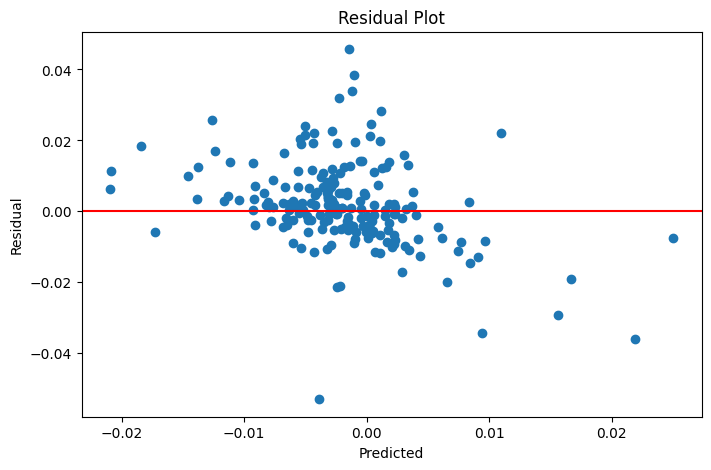

In [13]:
residuals = y_test - pred

plt.figure(figsize=(8,5))

plt.scatter(pred, residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# XGBOOST CLASSIFICATION

In [14]:
print(df["Target_Next_1D_Direction"].value_counts())
print(df["Target_Next_1D_Direction"].nunique())

Target_Next_1D_Direction
0.0    580
1.0    387
Name: count, dtype: int64
2


In [15]:
df["Target_Next_1D_Direction"] = (df["Target_Next_1D_Return"] > 0).astype(int)

In [16]:
selected_features = [
    'Rolling_Return_Zscore_60D',
    'Log_Return',
    'Return_5D',
    'Lag_Log_Return_1D',
    'Lag_Log_Return_5D',
    'Lag_Log_Return_20D',
    'Expanding_Mean_Log_Return',
    'Volume_Ratio_20D',
    'Return_10D',
    'Volume_Pct_Change',
    'Volume_Rolling_Std_20D',
    'MACD_Hist',
    'Rolling_Vol_30D',
    'EMA20_to_SMA20',
    'ATR_14D_Norm',
    'Volume_Rolling_Avg_20D',
    'MACD_Signal',
    'Volume',
    'Cumulative_Return',
    'Turn Over'
]

In [17]:
X = df[selected_features]
y = df["Target_Next_1D_Direction"]

In [18]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]


In [19]:
from xgboost import XGBClassifier

xgb_model= XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [20]:
val_pred = xgb_model.predict(X_val)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))

Validation Accuracy: 0.6620689655172414


In [21]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [22]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("========== XGBoost Classification ==========")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC AUC  :", xgb_auc)

========== XGBoost Classification ==========
Accuracy : 0.5342465753424658
Precision: 0.4444444444444444
Recall   : 0.05970149253731343
F1 Score : 0.10526315789473684
ROC AUC  : 0.5545059512563763


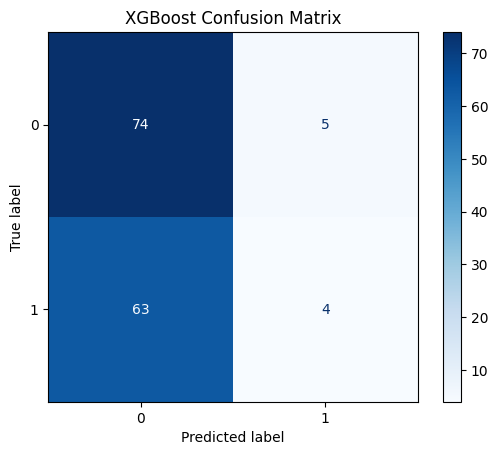

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

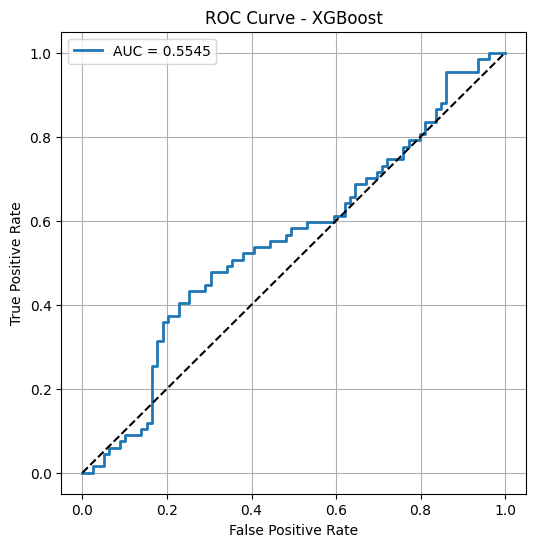

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {xgb_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.54      0.94      0.69        79
           1       0.44      0.06      0.11        67

    accuracy                           0.53       146
   macro avg       0.49      0.50      0.40       146
weighted avg       0.50      0.53      0.42       146



In [26]:
classification_results = {
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC-AUC": xgb_auc
}

import pandas as pd

results_df = pd.DataFrame(classification_results, index=["XGBoost"])
print(results_df)

         Accuracy  Precision    Recall  F1 Score   ROC-AUC
XGBoost  0.534247   0.444444  0.059701  0.105263  0.554506


# ARIMA Regression

In [27]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\Banking_final_model_ready.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

series = df['Target_Next_1D_Return']

In [29]:
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

In [31]:
model = ARIMA(train, order=(1,0,1))
model_fit = model.fit()

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [32]:
forecast = model_fit.forecast(steps=len(test))

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [33]:
print(forecast.head())
print(test.head())

773   -0.000824
774   -0.000596
775   -0.000624
776   -0.000621
777   -0.000621
Name: predicted_mean, dtype: float64
Date
2025-02-11   -0.000586
2025-02-12   -0.002309
2025-02-13    0.009772
2025-02-16    0.021448
2025-02-17    0.002238
Name: Target_Next_1D_Return, dtype: float64


In [34]:
arima_rmse = np.sqrt(mean_squared_error(test, forecast))
arima_mae = mean_absolute_error(test, forecast)
arima_r2 = r2_score(test, forecast)

print("========== ARIMA Results ==========")
print("RMSE :", arima_rmse)
print("MAE  :", arima_mae)
print("R²   :", arima_r2)

========== ARIMA Results ==========
RMSE : 0.011612067494412872
MAE  : 0.008157883692603172
R²   : -0.00260225239043943


In [35]:
print(series.head())
print(series.describe())

Date
2021-09-12    0.008687
2021-09-13   -0.002080
2021-09-14   -0.010546
2021-09-15   -0.021338
2021-09-16   -0.027342
Name: Target_Next_1D_Return, dtype: float64
count    967.000000
mean      -0.000502
std        0.013018
min       -0.061522
25%       -0.007424
50%       -0.002237
75%        0.004449
max        0.094359
Name: Target_Next_1D_Return, dtype: float64


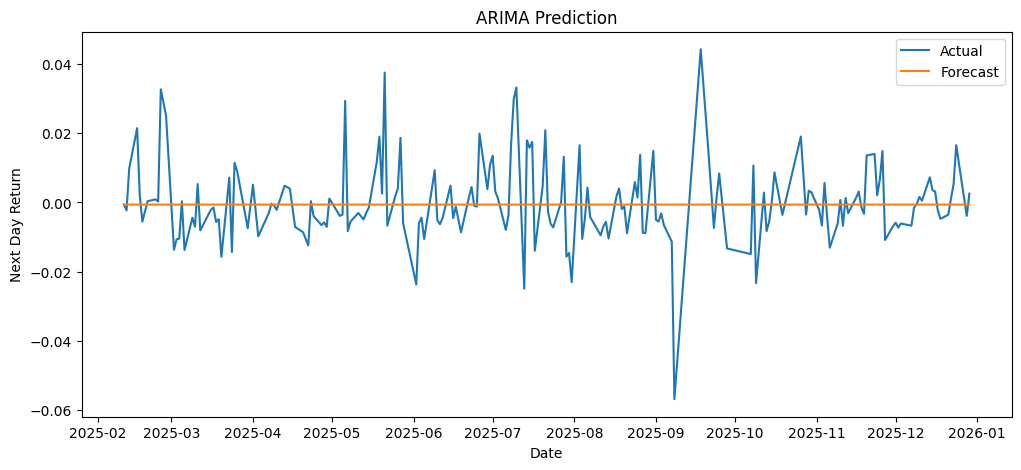

In [36]:
plt.figure(figsize=(12,5))

plt.plot(test.index,test.values,label="Actual")

plt.plot(test.index,forecast,label="Forecast")

plt.title("ARIMA Prediction")

plt.xlabel("Date")

plt.ylabel("Next Day Return")

plt.legend()

plt.show()

# ARIMA Classification

In [37]:
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import numpy as np

In [38]:
y = df["Target_Next_1D_Return"]

In [39]:
n = len(y)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = y.iloc[:train_end]
validation = y.iloc[train_end:val_end]
test = y.iloc[val_end:]

print(train.shape)
print(validation.shape)
print(test.shape)

(676,)
(145,)
(146,)


In [40]:
arima_model = ARIMA(train, order=(5,1,0))

arima_model_fit = arima_model.fit()

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [41]:
forecast = arima_model_fit.forecast(steps=len(validation) + len(test))

forecast = np.array(forecast)

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [42]:
forecast_test = forecast[len(validation):]

In [43]:
pred_class = (forecast_test > 0).astype(int)

true_class = (test > 0).astype(int)

In [44]:
arima_accuracy = accuracy_score(true_class, pred_class)
arima_precision = precision_score(true_class, pred_class)
arima_recall = recall_score(true_class, pred_class)
arima_f1 = f1_score(true_class, pred_class)
arima_auc = roc_auc_score(true_class, forecast_test)

print("========== ARIMA Classification ==========")
print("Accuracy :", arima_accuracy)
print("Precision:", arima_precision)
print("Recall   :", arima_recall)
print("F1 Score :", arima_f1)
print("ROC AUC  :", arima_auc)

========== ARIMA Classification ==========
Accuracy : 0.541095890410959
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.5


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [45]:
print(classification_report(true_class, pred_class))

              precision    recall  f1-score   support

           0       0.54      1.00      0.70        79
           1       0.00      0.00      0.00        67

    accuracy                           0.54       146
   macro avg       0.27      0.50      0.35       146
weighted avg       0.29      0.54      0.38       146



C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

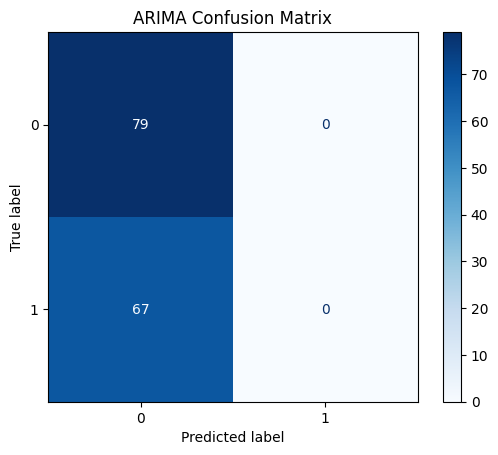

In [46]:
cm = confusion_matrix(true_class, pred_class)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("ARIMA Confusion Matrix")

plt.show()

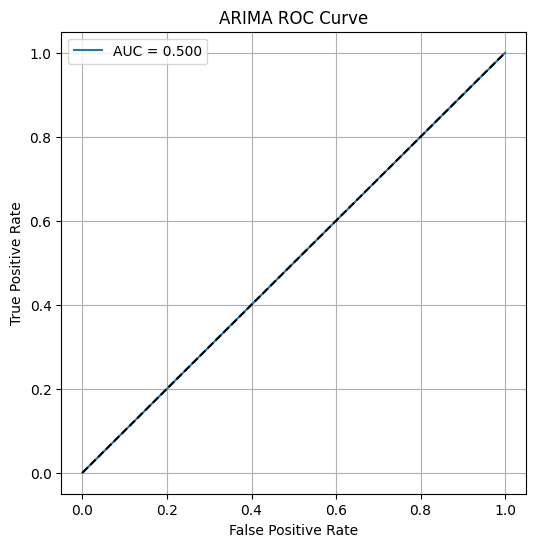

In [48]:
fpr, tpr, _ = roc_curve(true_class, forecast_test)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {arima_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ARIMA ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# LSTM Regression

In [49]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\banking_final_model_ready.csv")
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

In [51]:
X = df.drop(columns=[
    'Date',
    'Target_Next_1D_Return',
    'Target_Next_1D_Direction'
])

y = df['Target_Next_1D_Return']

In [52]:
feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(
    y.values.reshape(-1,1)
)

# 7-Day Sequences

In [53]:
time_step = 7

X_seq = []

y_seq = []

for i in range(len(X_scaled)-time_step):

    X_seq.append(X_scaled[i:i+time_step])

    y_seq.append(y_scaled[i+time_step])

X_seq = np.array(X_seq)

y_seq = np.array(y_seq)

In [54]:
split = int(len(X_seq)*0.8)

X_train = X_seq[:split]

X_test = X_seq[split:]

y_train = y_seq[:split]

y_test = y_seq[split:]

In [55]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(7,X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(16,activation='relu'))

model.add(Dense(1))

model.compile(

    optimizer='adam',

    loss='mse'
)

model.summary()

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 7, 64)               │          26,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,073 (152.63 KB)

 Trainable params: 39,073 (152.63 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
history = model.fit(

    X_train,

    y_train,

    epochs=50,

    batch_size=32,

    validation_data=(X_test,y_test),

    verbose=1
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0181 - val_loss: 0.0089
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0116 - val_loss: 0.0064
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0097 - val_loss: 0.0058
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0095 - val_loss: 0.0057
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0090 - val_loss: 0.0057
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0091 - val_loss: 0.0068
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0091 - val_loss: 0.0058
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0084 - val_loss: 0.0063
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0083 - val_loss: 0.0063
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0084 - val_loss: 0.0065
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0082 - val_loss: 0.0060
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

In [57]:
pred = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


In [58]:
pred = target_scaler.inverse_transform(pred)

actual = target_scaler.inverse_transform(y_test)

In [59]:
lstm_rmse = np.sqrt(mean_squared_error(actual, pred))
lstm_mae = mean_absolute_error(actual, pred)
lstm_r2 = r2_score(actual, pred)

print("========== LSTM Results ==========")
print("RMSE :", lstm_rmse)
print("MAE  :", lstm_mae)
print("R²   :", lstm_r2)

========== LSTM Results ==========
RMSE : 0.012769334237279627
MAE  : 0.008800424035669179
R²   : -0.2001563959876147


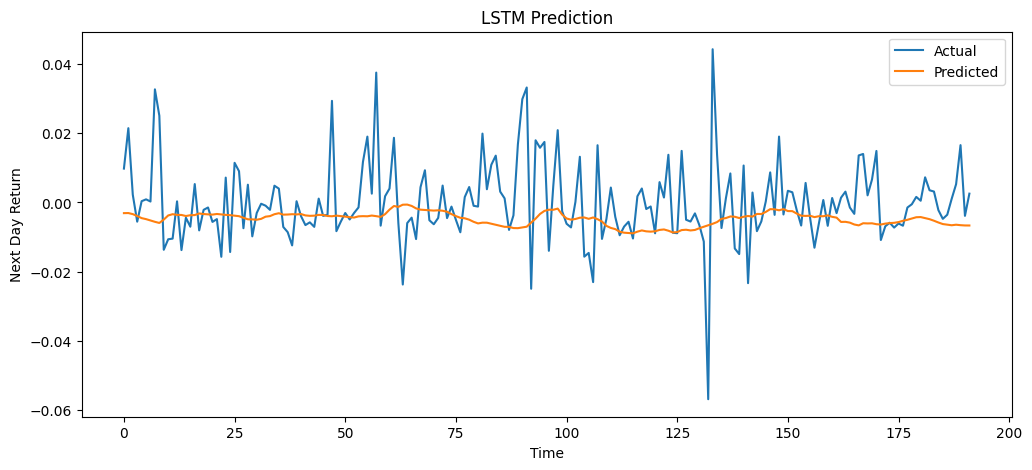

In [60]:
plt.figure(figsize=(12,5))

plt.plot(actual,label="Actual")

plt.plot(pred,label="Predicted")

plt.title("LSTM Prediction")

plt.xlabel("Time")

plt.ylabel("Next Day Return")

plt.legend()

plt.show()

# LSTM Classification

In [61]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt

In [62]:
y_class = df["Target_Next_1D_Direction"]

In [63]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [64]:
sequence_length = 7

X_seq = []
y_seq = []

for i in range(sequence_length, len(X_scaled)):
    X_seq.append(X_scaled[i-sequence_length:i])
    y_seq.append(y_class.iloc[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

In [65]:
n = len(X_seq)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_seq[:train_end]
X_val = X_seq[train_end:val_end]
X_test = X_seq[val_end:]

y_train = y_seq[:train_end]
y_val = y_seq[train_end:val_end]
y_test = y_seq[val_end:]

In [66]:
print(np.unique(y_test))

[0. 1.]


In [67]:
lstm_prob = model.predict(X_test).flatten()

lstm_pred = (lstm_prob >= 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


In [68]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [69]:
lstm_accuracy = accuracy_score(y_test, lstm_pred)
lstm_precision = precision_score(y_test, lstm_pred)
lstm_recall = recall_score(y_test, lstm_pred)
lstm_f1 = f1_score(y_test, lstm_pred)
lstm_auc = roc_auc_score(y_test, lstm_prob)

print("========== LSTM Classification ==========")
print("Accuracy :", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall   :", lstm_recall)
print("F1 Score :", lstm_f1)
print("ROC AUC  :", lstm_auc)

========== LSTM Classification ==========
Accuracy : 0.5416666666666666
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.508935508935509


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [70]:
print("Unique values in y_train:", np.unique(y_train))
print("Unique values in y_val:", np.unique(y_val))
print("Unique values in y_test:", np.unique(y_test))

Unique values in y_train: [0. 1.]
Unique values in y_val: [0. 1.]
Unique values in y_test: [0. 1.]


In [71]:
lstm_model = Sequential()

lstm_model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(32))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1, activation="sigmoid"))

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.6042 - loss: 0.6796 - val_accuracy: 0.6528 - val_loss: 0.6508
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6012 - loss: 0.6722 - val_accuracy: 0.6528 - val_loss: 0.6482
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6012 - loss: 0.6739 - val_accuracy: 0.6528 - val_loss: 0.6469
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6012 - loss: 0.6703 - val_accuracy: 0.6528 - val_loss: 0.6486
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6027 - loss: 0.6674 - val_accuracy: 0.6528 - val_loss: 0.6438
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6012 - loss: 0.6660 - val_accuracy: 0.6528 - val_loss: 0.6457
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6012 - loss: 0.6698 - val_accuracy: 0.6458 - val_loss: 0.6472
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5848 - loss: 0.6705 - val_accuracy: 0.6042 - val_loss: 0.

In [72]:
prob = lstm_model.predict(X_test).flatten()
pred = (prob >= 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step 


In [73]:
pred = pred.flatten()
prob = prob.flatten()

In [74]:
lstm_results = {
    "Accuracy": lstm_accuracy,
    "Precision": lstm_precision,
    "Recall": lstm_recall,
    "F1 Score": lstm_f1,
    "ROC-AUC": lstm_auc
}

lstm_df = pd.DataFrame(lstm_results, index=["LSTM"])
print(lstm_df)

      Accuracy  Precision  Recall  F1 Score   ROC-AUC
LSTM  0.541667        0.0     0.0       0.0  0.508936


In [75]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.54      0.88      0.67        78
         1.0       0.44      0.11      0.17        66

    accuracy                           0.53       144
   macro avg       0.49      0.50      0.42       144
weighted avg       0.49      0.53      0.44       144



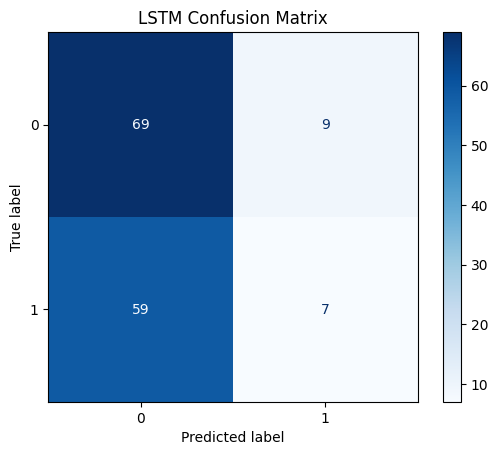

In [76]:
cm = confusion_matrix(y_test, pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")

plt.show()

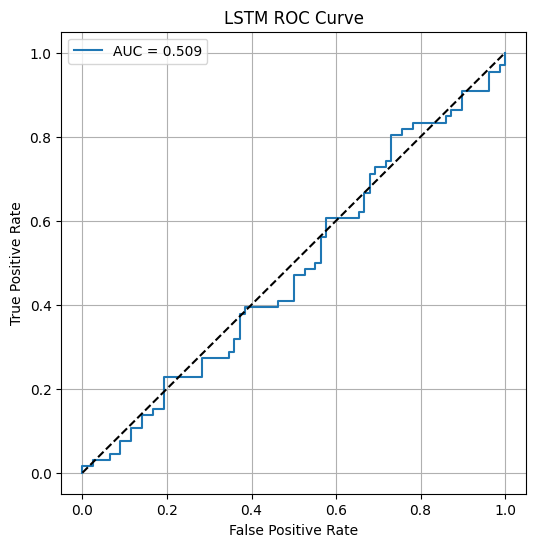

In [78]:
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {lstm_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LSTM ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# Comparison Table for Regression

In [79]:
results = pd.DataFrame({
    "Model": ["XGBoost", "ARIMA", "LSTM"],
    "RMSE": [xgb_rmse, arima_rmse, lstm_rmse],
    "MAE": [xgb_mae, arima_mae, lstm_mae],
    "R2": [xgb_r2, arima_r2, lstm_r2]
})

print(results)

     Model      RMSE       MAE        R2
0  XGBoost  0.012414  0.008762 -0.145880
1    ARIMA  0.011612  0.008158 -0.002602
2     LSTM  0.012769  0.008800 -0.200156


# Best Model

In [80]:
best = results.loc[results['RMSE'].idxmin()]

print("Best Model:")
print(best)

Best Model:
Model       ARIMA
RMSE     0.011612
MAE      0.008158
R2      -0.002602
Name: 1, dtype: object


In [81]:
print("XGBoost")
print(xgb_rmse, xgb_mae, xgb_r2)

print("\nARIMA")
print(arima_rmse, arima_mae, arima_r2)

print("\nLSTM")
print(lstm_rmse, lstm_mae, lstm_r2)

XGBoost
0.012414087169305456 0.008761938529635426 -0.14588003900171453

ARIMA
0.011612067494412872 0.008157883692603172 -0.00260225239043943

LSTM
0.012769334237279627 0.008800424035669179 -0.2001563959876147


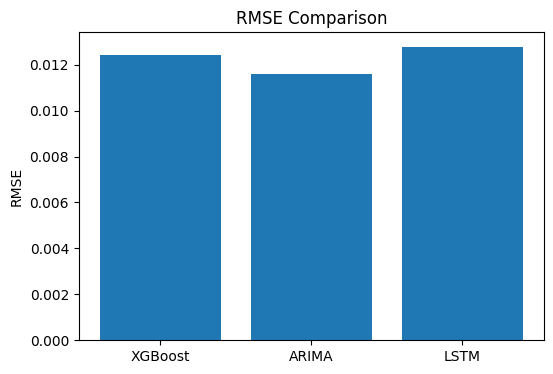

In [82]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

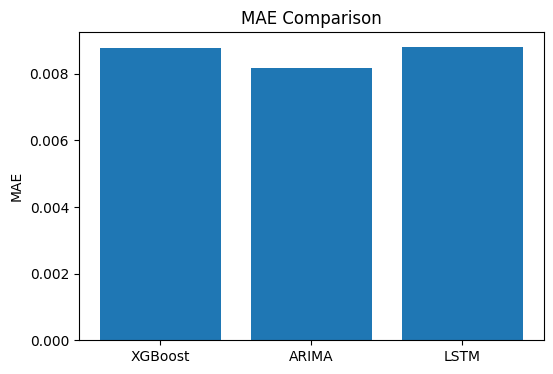

In [83]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["MAE"])
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()

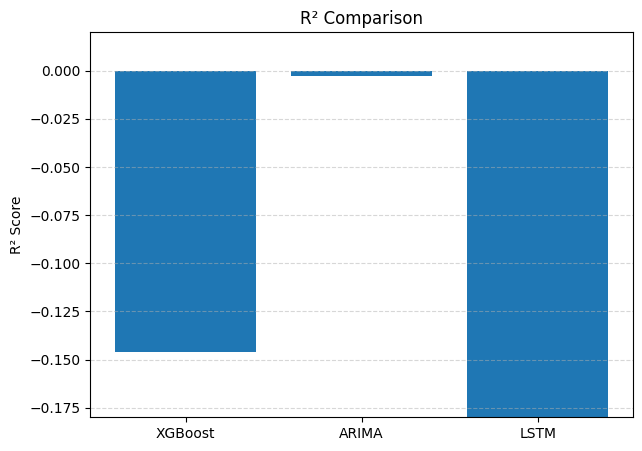

In [84]:
plt.figure(figsize=(7,5))

plt.bar(results["Model"], results["R2"])

plt.title("R² Comparison")
plt.ylabel("R² Score")

plt.ylim(-0.18, 0.02)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [85]:
print(results.round(4))

     Model    RMSE     MAE      R2
0  XGBoost  0.0124  0.0088 -0.1459
1    ARIMA  0.0116  0.0082 -0.0026
2     LSTM  0.0128  0.0088 -0.2002


# Comparison of Classification

In [86]:
classification_results = pd.DataFrame({
    "Model": ["XGBoost", "ARIMA", "LSTM"],
    "Accuracy": [xgb_accuracy, arima_accuracy, lstm_accuracy],
    "Precision": [xgb_precision, arima_precision, lstm_precision],
    "Recall": [xgb_recall, arima_recall, lstm_recall],
    "F1 Score": [xgb_f1, arima_f1, lstm_f1],
    "ROC-AUC": [xgb_auc, arima_auc, lstm_auc]
})

print(classification_results.round(4))

     Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  XGBoost    0.5342     0.4444  0.0597    0.1053   0.5545
1    ARIMA    0.5411     0.0000  0.0000    0.0000   0.5000
2     LSTM    0.5417     0.0000  0.0000    0.0000   0.5089


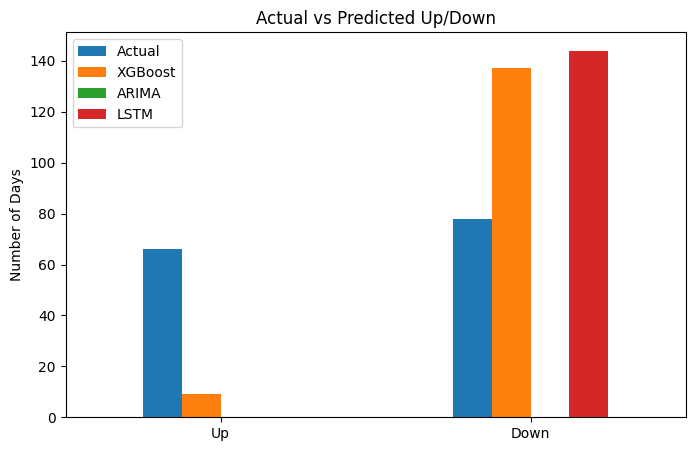

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Actual": [(y_test == 1).sum(), (y_test == 0).sum()],
    "XGBoost": [(xgb_pred == 1).sum(), (xgb_pred == 0).sum()],
    "ARIMA": [(forecast == 1).sum(), (forecast == 0).sum()],
    "LSTM": [(lstm_pred == 1).sum(), (lstm_pred == 0).sum()]
}, index=["Up", "Down"])

comparison.plot(kind="bar", figsize=(8,5))
plt.title("Actual vs Predicted Up/Down")
plt.ylabel("Number of Days")
plt.xticks(rotation=0)
plt.show()